<a href="https://colab.research.google.com/github/smonodeep/DynamicValuationGovernance/blob/main/1_Exploratory_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/final_model_dataset.csv')
df["delta_repo"] = df["repo_rate"].diff()
df["policy_shock"] = (abs(df["delta_repo"]) >= 0.25).astype(int)
display(df.columns.to_list())
display(df.head())
display(df.describe())

,city,quarter,rent,hpi,rent_growth,hpi_growth,valuation_gap,repo_rate,hpi_lag,rent_lag,repo_growth,repo_lag
0,bangalore,Q1 2015,104.4500,61.806841,0.043538,0.237475,-0.193937,7.782887,NaN,NaN,NaN,NaN
1,bangalore,Q1 2016,114.6000,71.406332,0.092739,0.144372,-0.051633,7.657853,0.237475,0.043538,-0.016196,NaN
2,bangalore,Q1 2017,121.9875,75.582470,0.062471,0.056838,0.005633,6.962920,0.144372,0.092739,-0.095133,-0.016196
3,bangalore,Q1 2018,145.2250,77.997789,0.174366,0.031456,0.142910,7.466353,0.056838,0.062471,0.069808,-0.095133
4,bangalore,Q1 2019,144.7375,83.885498,-0.003363,0.072772,-0.076135,7.397403,0.031456,0.174366,-0.009278,0.069808


In [ ]:

# Create a sortable quarter column for chronological plotting
df['year_quarter'] = df['quarter'].str.extract(r'Q(\d) (\d{4})').astype(int).pipe(lambda x: x[1] * 4 + x[0] - 1)
df = df.sort_values(by=['city', 'year_quarter'])

### Average Rent and HPI by City

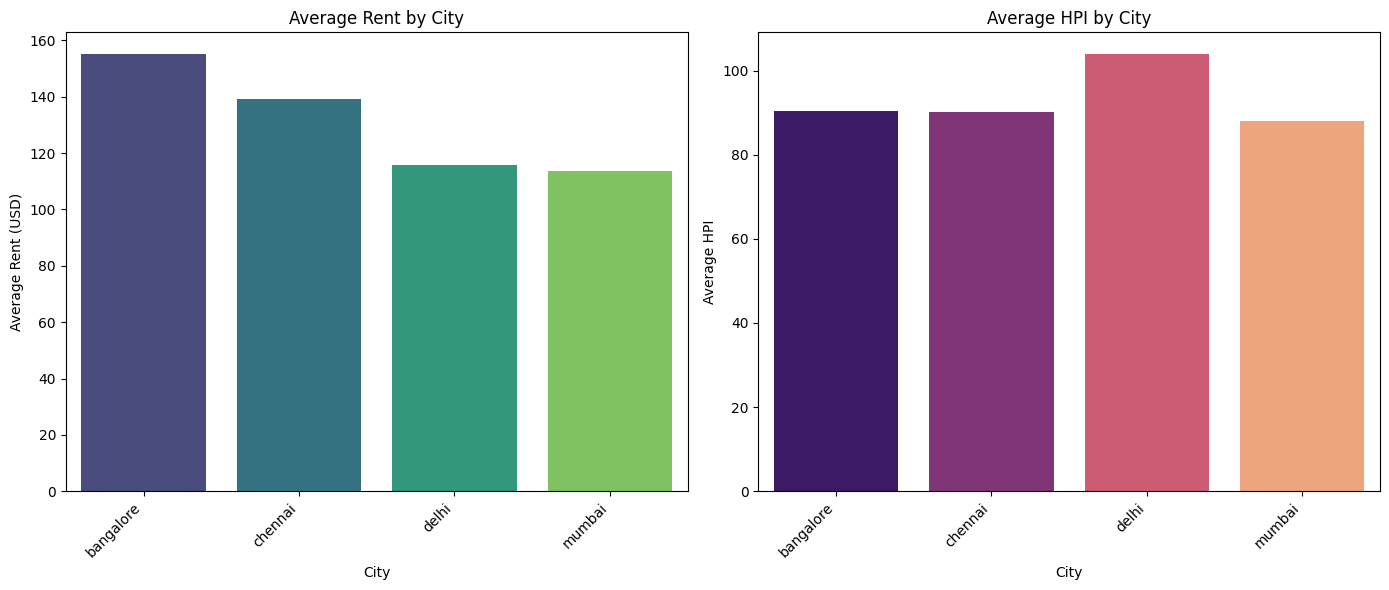

In [ ]:
# Calculate average rent and HPI by city
avg_by_city = df.groupby('city')[['rent', 'hpi']].mean().reset_index()

Plot Rent Growth

Plot Moving Average for Rent Growth to Extract Signal

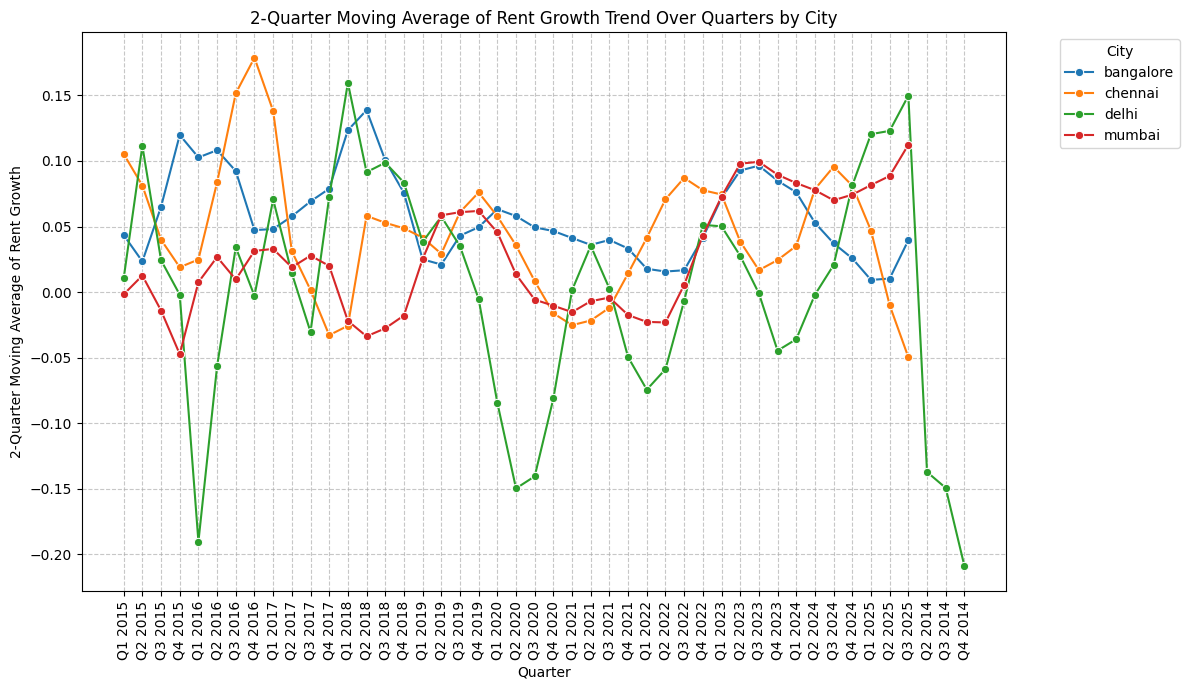

In [ ]:
# Ensure df is loaded and 'year_quarter' is created for sorting
# Re-create 'year_quarter' if not already present, and sort for correct rolling calculation
if 'year_quarter' not in df.columns:
    df['year_quarter'] = df['quarter'].str.extract(r'Q(\d) (\d{4})').astype(int).pipe(lambda x: x[1] * 4 + x[0] - 1)
df = df.sort_values(by=['city', 'year_quarter'])

# Calculate the 2-quarter moving average for rent_growth, grouped by city
df['rent_growth_ma2'] = df.groupby('city')['rent_growth'].transform(lambda x: x.rolling(window=2, min_periods=1).mean())

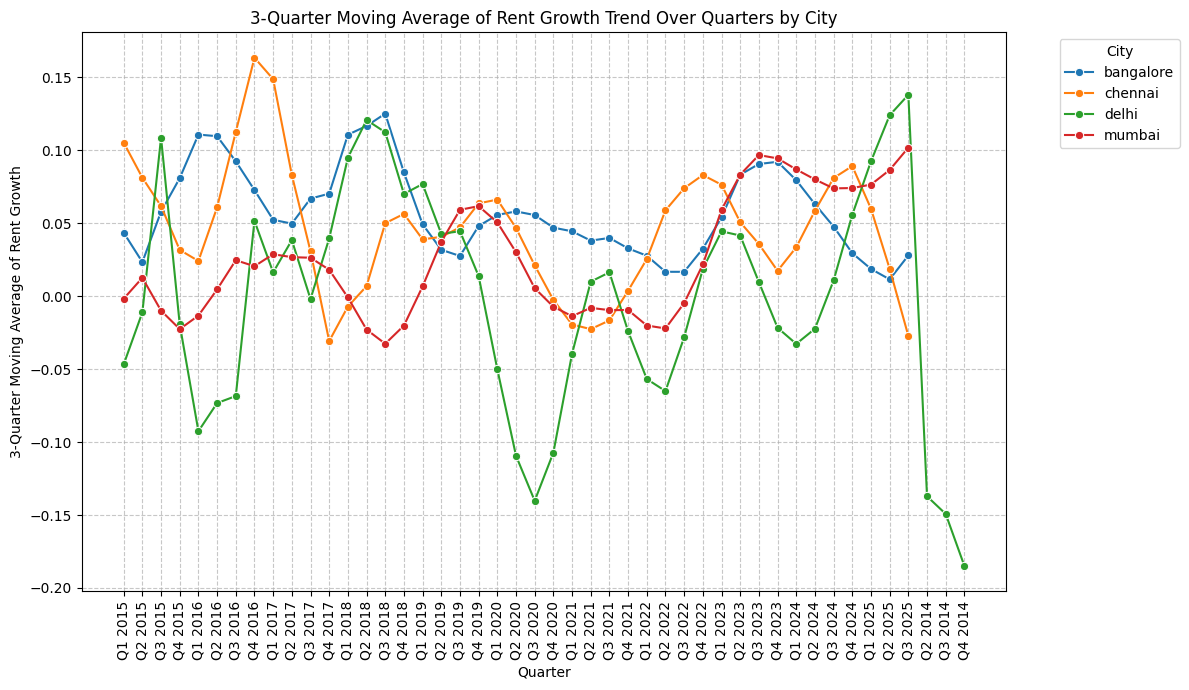

In [ ]:
# Ensure 'year_quarter' and 'regime' are defined if not already
# (Assuming these transformations might be needed for other parts of df within this cell's context
#  or for future use, as the original notebook defines them earlier)
# If these are not used within this specific plot, they can be omitted.
# However, to be safe and ensure df is fully prepared as intended by earlier cells:
if 'year_quarter' not in df.columns:
    df['year_quarter'] = df['quarter'].str.extract(r'Q(\d) (\d{4})').astype(int).pipe(lambda x: x[1] * 4 + x[0] - 1)
    df = df.sort_values(by=['city', 'year_quarter'])

# Calculate rent_growth if it doesn't exist (assuming this might be a derived column needed for MA)
# This is a placeholder; usually, you'd ensure previous cells run or add all dependencies.
# For this specific error (df not defined), just defining df is the direct fix.
# The earlier notebook state implies 'rent_growth' and 'valuation_gap' already exist in df.

df['rent_growth_ma3'] = df.groupby('city')['rent_growth'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

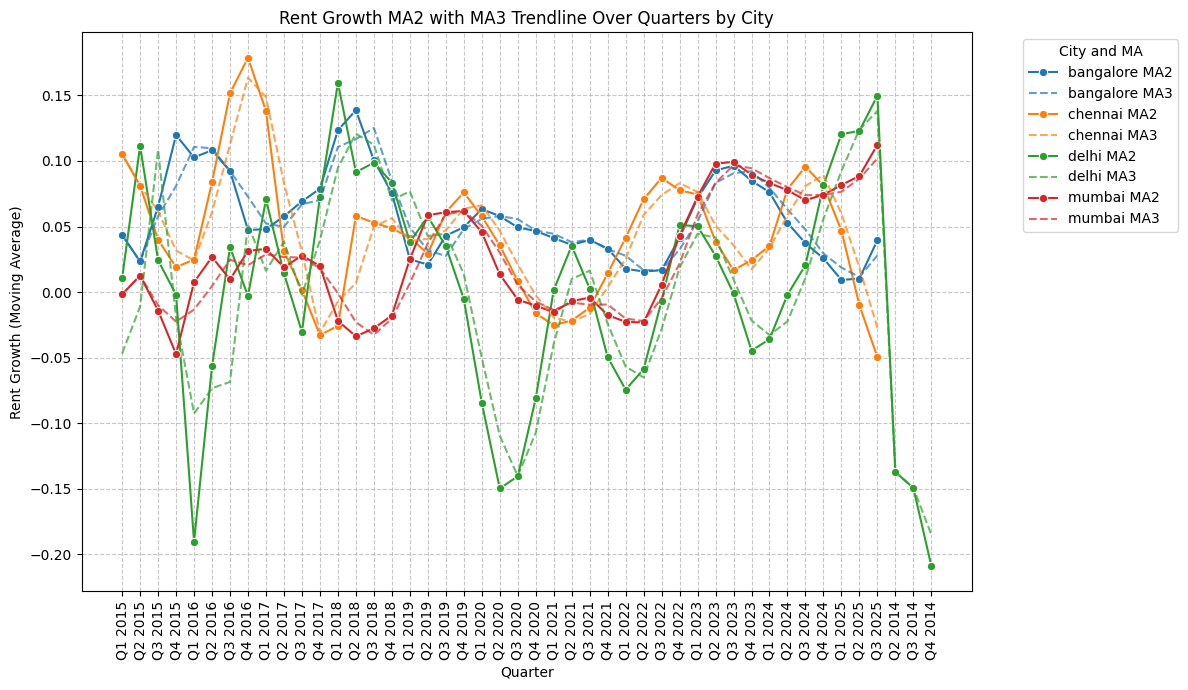

In [ ]:


# Re-create 'year_quarter' if not already present, and sort for correct rolling calculation
if 'year_quarter' not in df.columns:
    df['year_quarter'] = df['quarter'].str.extract(r'Q(\d) (\d{4})').astype(int).pipe(lambda x: x[1] * 4 + x[0] - 1)
df = df.sort_values(by=['city', 'year_quarter'])

# Calculate the 2-quarter moving average for rent_growth, grouped by city
df['rent_growth_ma2'] = df.groupby('city')['rent_growth'].transform(lambda x: x.rolling(window=2, min_periods=1).mean())

# Calculate the 3-quarter moving average for rent_growth, grouped by city (for trendline)
df['rent_growth_ma3'] = df.groupby('city')['rent_growth'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

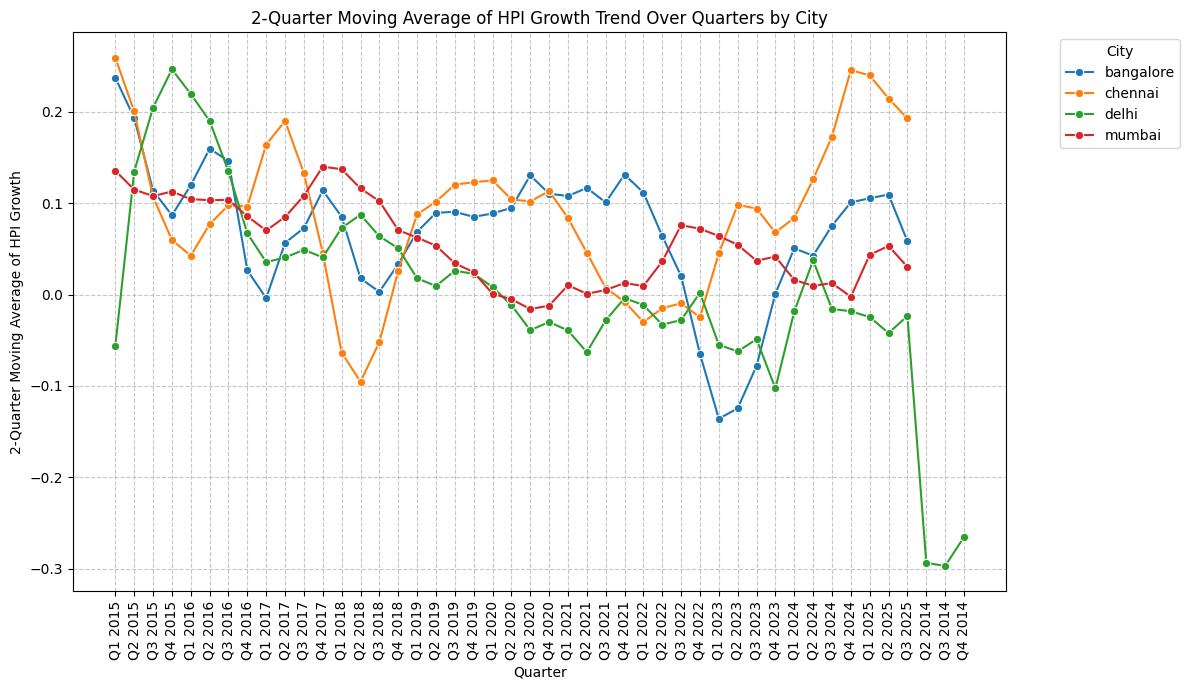

In [ ]:
# Ensure df is loaded and 'year_quarter' is created for sorting
# Re-create 'year_quarter' if not already present, and sort for correct rolling calculation
if 'year_quarter' not in df.columns:
    df['year_quarter'] = df['quarter'].str.extract(r'Q(\d) (\d{4})').astype(int).pipe(lambda x: x[1] * 4 + x[0] - 1)
df = df.sort_values(by=['city', 'year_quarter'])

# Calculate the 2-quarter moving average for hpi_growth, grouped by city
df['hpi_growth_ma2'] = df.groupby('city')['hpi_growth'].transform(lambda x: x.rolling(window=2, min_periods=1).mean())

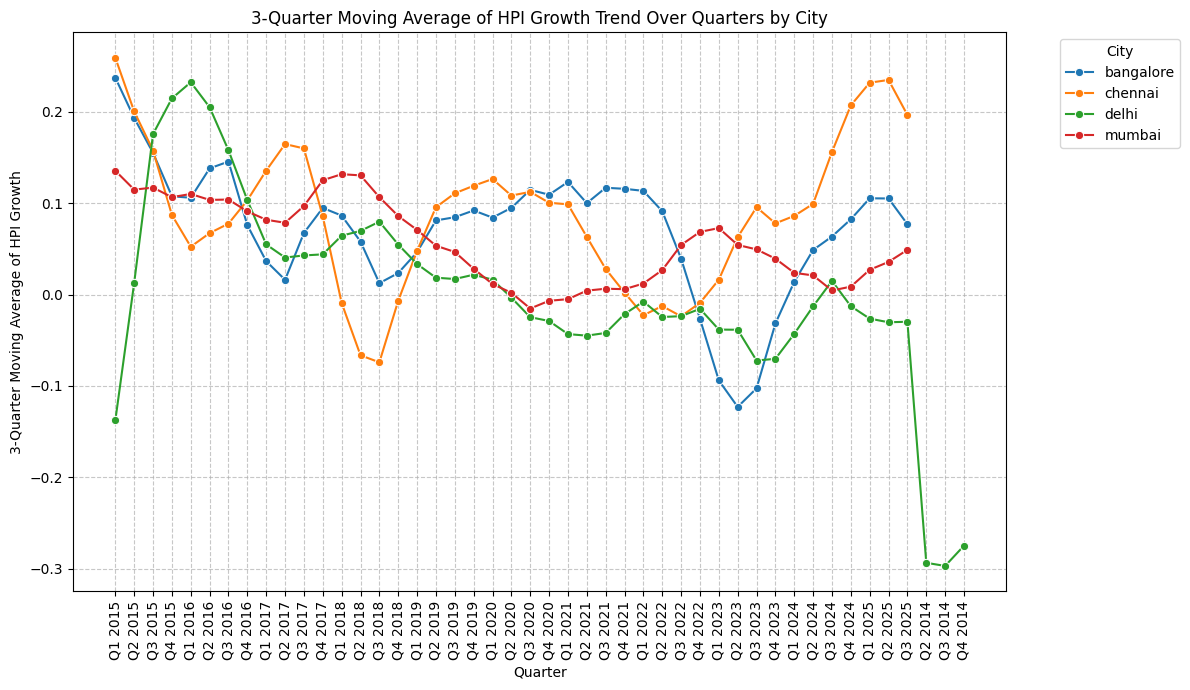

In [ ]:
# Re-create 'year_quarter' if not already present, and sort for correct rolling calculation
if 'year_quarter' not in df.columns:
    df['year_quarter'] = df['quarter'].str.extract(r'Q(\d) (\d{4})').astype(int).pipe(lambda x: x[1] * 4 + x[0] - 1)
df = df.sort_values(by=['city', 'year_quarter'])

# Calculate the 3-quarter moving average for hpi_growth, grouped by city
df['hpi_growth_ma3'] = df.groupby('city')['hpi_growth'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

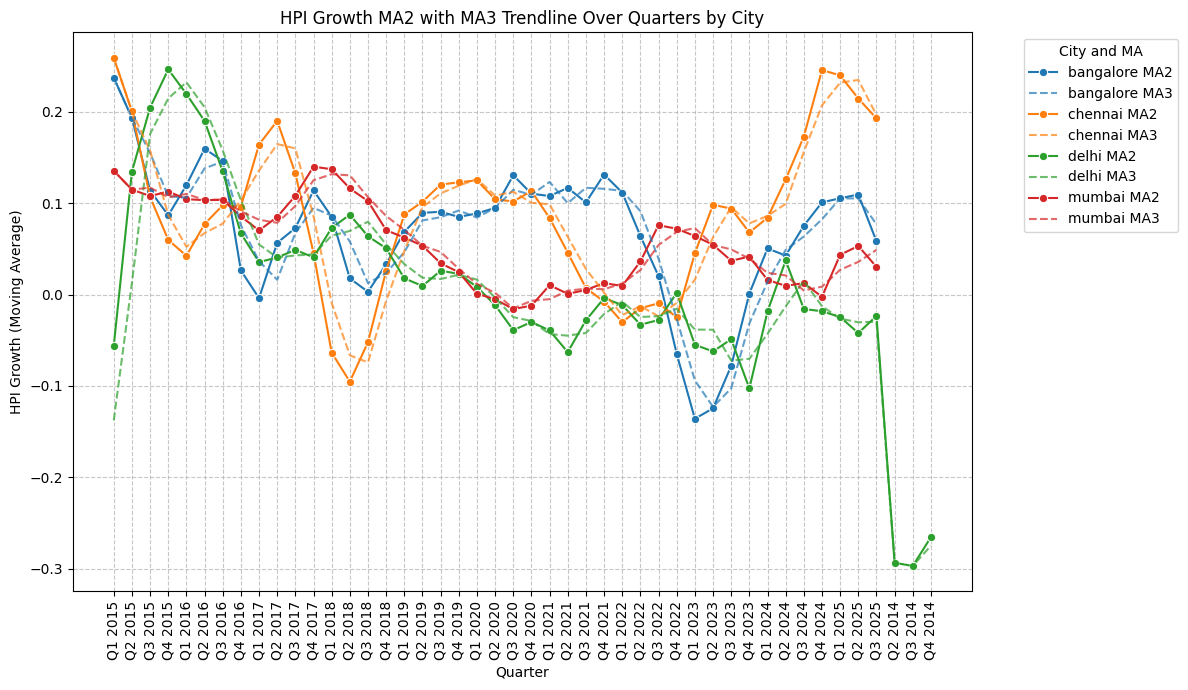

In [ ]:
# Re-create 'year_quarter' if not already present, and sort for correct rolling calculation
if 'year_quarter' not in df.columns:
    df['year_quarter'] = df['quarter'].str.extract(r'Q(\d) (\d{4})').astype(int).pipe(lambda x: x[1] * 4 + x[0] - 1)
df = df.sort_values(by=['city', 'year_quarter'])

# Calculate the 2-quarter moving average for hpi_growth, grouped by city
df['hpi_growth_ma2'] = df.groupby('city')['hpi_growth'].transform(lambda x: x.rolling(window=2, min_periods=1).mean())

# Calculate the 3-quarter moving average for hpi_growth, grouped by city (for trendline)
df['hpi_growth_ma3'] = df.groupby('city')['hpi_growth'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

Plot

### Repo Growth Trend Over Quarters- This does not have economic sense so upstream created two new variables, delta_repo and policy_shock

### Repo Lag Trend Over Quarters

### Moving Average of Repo Growth

In [ ]:
df['repo_growth_ma2'] = df.groupby('city')['repo_growth'].transform(lambda x: x.rolling(window=2, min_periods=1).mean())

,city,quarter,delta_repo,policy_shock
0,bangalore,Q1 2015,NaN,1
11,bangalore,Q2 2015,1.073457,1
22,bangalore,Q3 2015,NaN,1
33,bangalore,Q4 2015,NaN,1
1,bangalore,Q1 2016,-0.125033,1


,city,quarter,delta_repo,policy_shock
163,mumbai,Q3 2024,-0.239833,1
174,mumbai,Q4 2024,-0.489833,1
142,mumbai,Q1 2025,-0.362167,1
153,mumbai,Q2 2025,NaN,1
164,mumbai,Q3 2025,NaN,1


First, we will calculate `hpi_lag` as the previous quarter's HPI, grouped by city, and then create the `regime` variable using `pd.qcut`.

In [ ]:
df['hpi_lag'] = df.groupby('city')['hpi'].shift(1)
df['regime'] = pd.qcut(df['hpi_lag'], q=3, labels=['low', 'mid', 'high'], duplicates='drop')

,city,quarter,hpi,hpi_lag,regime
0,bangalore,Q1 2015,61.806841,NaN,NaN
11,bangalore,Q2 2015,59.819703,61.806841,low
22,bangalore,Q3 2015,62.725676,59.819703,low
33,bangalore,Q4 2015,69.447592,62.725676,low
1,bangalore,Q1 2016,71.406332,69.447592,low


Goiing to test for all the other variables

In [38]:
print('DataFrame Shape:')
print(df.shape)

DataFrame Shape:
(175, 23)


In [39]:
print('List of Columns:')
print(df.columns.tolist())

List of Columns:
['city', 'quarter', 'rent', 'hpi', 'rent_growth', 'hpi_growth', 'valuation_gap', 'repo_rate', 'hpi_lag', 'rent_lag', 'repo_growth', 'repo_lag', 'delta_repo', 'policy_shock', 'policy_shock1', 'year_quarter', 'rent_growth_ma2', 'rent_growth_ma3', 'hpi_growth_ma2', 'hpi_growth_ma3', 'repo_growth_ma2', 'regime', 'quarter_dt']


In [40]:
print('Column Data Types:')
print(df.info())

Column Data Types:
<class 'pandas.core.frame.DataFrame'>
Index: 175 entries, 0 to 164
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   city             175 non-null    object        
 1   quarter          175 non-null    object        
 2   rent             175 non-null    float64       
 3   hpi              175 non-null    float64       
 4   rent_growth      175 non-null    float64       
 5   hpi_growth       175 non-null    float64       
 6   valuation_gap    175 non-null    float64       
 7   repo_rate        167 non-null    float64       
 8   hpi_lag          171 non-null    float64       
 9   rent_lag         171 non-null    float64       
 10  repo_growth      161 non-null    float64       
 11  repo_lag         157 non-null    float64       
 12  delta_repo       158 non-null    float64       
 13  policy_shock     175 non-null    int64         
 14  policy_shock1    175 non-nul

In [41]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Drop rows with any NaN values, as OLS cannot handle them directly
df_model = df.dropna().copy()

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after dropping NaNs: {df_model.shape}")

# Define the OLS formula with interaction terms
formula = (
    "valuation_gap ~ repo_rate + hpi_lag + rent_lag + repo_growth + repo_lag + "
    "rent_growth_ma2 + rent_growth_ma3 + hpi_growth_ma2 + hpi_growth_ma3 + "
    "C(city) + C(regime) + repo_rate:hpi_lag + rent_growth_ma2:hpi_growth_ma2 + "
    "repo_rate:C(regime) + hpi_lag:C(regime) + repo_growth_ma2:C(city)"
)

# Fit the OLS model
ols_model = smf.ols(formula=formula, data=df_model)
ols_results = ols_model.fit()

# Print the model summary
print(ols_results.summary())


Original DataFrame shape: (175, 23)
DataFrame shape after dropping NaNs: (148, 23)
                            OLS Regression Results                            
Dep. Variable:          valuation_gap   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     28.85
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.70e-39
Time:                        11:24:53   Log-Likelihood:                 291.03
No. Observations:                 148   AIC:                            -532.1
Df Residuals:                     123   BIC:                            -457.1
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------

In [42]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# df_model is already prepared from the previous OLS cell, with NaNs dropped.
# If you run this cell independently, ensure df_model is defined.
# df_model = df.dropna().copy()

print(f"DataFrame shape for new OLS model: {df_model.shape}")

# Define the new OLS formula based on the conceptual model
new_formula = (
    "valuation_gap ~ rent_growth_ma2 + hpi_growth_ma2 + repo_growth_ma2 + "
    "hpi_lag + rent_lag + C(regime) + repo_growth_ma2:C(regime)"
)

# Fit the new OLS model
new_ols_model = smf.ols(formula=new_formula, data=df_model)
new_ols_results = new_ols_model.fit()

# Print the model summary
print("\n--- New OLS Model Summary (Simplified) ---")
print(new_ols_results.summary())

DataFrame shape for new OLS model: (148, 23)

--- New OLS Model Summary (Simplified) ---
                            OLS Regression Results                            
Dep. Variable:          valuation_gap   R-squared:                       0.773
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     52.13
Date:                Sun, 03 May 2026   Prob (F-statistic):           4.34e-40
Time:                        11:24:53   Log-Likelihood:                 260.70
No. Observations:                 148   AIC:                            -501.4
Df Residuals:                     138   BIC:                            -471.4
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------

In [43]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# df_model is already prepared from previous OLS cells, with NaNs dropped.

print(f"DataFrame shape for final OLS model: {df_model.shape}")

# Define the new OLS formula with only significant variables
final_formula = (
    "valuation_gap ~ rent_growth_ma2 + hpi_growth_ma2 + \
                     repo_rate + C(regime) + hpi_lag + \
                     repo_rate:C(regime) + repo_rate:hpi_lag"
)

# Fit the new OLS model
final_ols_model = smf.ols(formula=final_formula, data=df_model)
final_ols_results = final_ols_model.fit()

# Print the model summary
print("\n--- Final OLS Model Summary (Significant Variables Only) ---")
print(final_ols_results.summary())

DataFrame shape for final OLS model: (148, 23)

--- Final OLS Model Summary (Significant Variables Only) ---
                            OLS Regression Results                            
Dep. Variable:          valuation_gap   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     55.44
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.67e-41
Time:                        11:24:53   Log-Likelihood:                 264.25
No. Observations:                 148   AIC:                            -508.5
Df Residuals:                     138   BIC:                            -478.5
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----

In [44]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# df_model is already prepared from previous OLS cells, with NaNs dropped.
# If this cell is run independently, ensure df_model is defined by running previous data prep cells.

print(f"DataFrame shape for OLS model: {df_model.shape}")

# Define the OLS formula based on the user's input
formula_user = (
    "valuation_gap ~ rent_growth_ma2 + hpi_growth_ma2 + C(regime) + repo_rate:C(regime)"
)

# Fit the OLS model
ols_model_user = smf.ols(formula=formula_user, data=df_model)
ols_results_user = ols_model_user.fit()

# Print the model summary
print("\n--- OLS Model Summary based on User's Formula ---")
print(ols_results_user.summary())

DataFrame shape for OLS model: (148, 23)

--- OLS Model Summary based on User's Formula ---
                            OLS Regression Results                            
Dep. Variable:          valuation_gap   R-squared:                       0.770
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     66.90
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.52e-41
Time:                        11:24:53   Log-Likelihood:                 259.77
No. Observations:                 148   AIC:                            -503.5
Df Residuals:                     140   BIC:                            -479.6
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------

Check with VIF

In [45]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
from patsy import dmatrices

# df_model is already prepared from previous OLS cells, with NaNs dropped.
# Ensure df_model is available. Assuming it is from the previous cell's context.

print(f"DataFrame shape for OLS model: {df_model.shape}")

# Create the specific 'regime_high' dummy variable as requested
df_model_temp = df_model.copy()
df_model_temp['regime_high'] = (df_model_temp['regime'] == 'high').astype(int)

# Define the OLS formula based on the user's exact input
formula_user_exact = (
    "valuation_gap ~ rent_growth_ma2 + hpi_growth_ma2 + regime_high + repo_rate + repo_rate:regime_high"
)

# Fit the OLS model
ols_model_user_exact = smf.ols(formula=formula_user_exact, data=df_model_temp)
ols_results_user_exact = ols_model_user_exact.fit()

# Print the model summary
print("\n--- OLS Model Summary based on User's Exact Formula ---")
print(ols_results_user_exact.summary())

# --- Calculate VIF ---
print("\n--- Variance Inflation Factor (VIF) ---")

# Get the design matrix (exog) from the formula, excluding the intercept
y_vif, X_vif = dmatrices(formula_user_exact, data=df_model_temp, return_type='dataframe')

# Check if 'Intercept' column is present and drop it for VIF calculation
if 'Intercept' in X_vif.columns:
    X_vif = X_vif.drop('Intercept', axis=1)

# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(len(X_vif.columns))]

print(vif_data.sort_values(by='VIF', ascending=False))

print("\nNote on VIF thresholds: VIF values above 5 or 10 are often considered indicative of significant multicollinearity.")

DataFrame shape for OLS model: (148, 23)

--- OLS Model Summary based on User's Exact Formula ---
                            OLS Regression Results                            
Dep. Variable:          valuation_gap   R-squared:                       0.767
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     93.34
Date:                Sun, 03 May 2026   Prob (F-statistic):           4.11e-43
Time:                        11:24:53   Log-Likelihood:                 258.78
No. Observations:                 148   AIC:                            -505.6
Df Residuals:                     142   BIC:                            -487.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------

Do Another Iteration

In [46]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
from patsy import dmatrices

# df_model is already prepared from previous OLS cells, with NaNs dropped.
# Ensure df_model is available.

print(f"DataFrame shape for OLS model: {df_model.shape}")

# Create the specific 'regime_high' dummy variable as requested
df_model_temp = df_model.copy()
df_model_temp['regime_high'] = (df_model_temp['regime'] == 'high').astype(int)

# Define the OLS formula based on the user's exact input
# The model spec is: valuation_gap_it = β1 * rent_growth_ma2_it + β2 * hpi_growth_ma2_it + β3 * repo_rate_t × regime_high + ε_it
# In patsy, `A:B` refers to the interaction term only. If main effects are also desired, `A*B` or `A + B + A:B` would be used.
# Based on the precise formula provided, only the interaction term `repo_rate:regime_high` is included along with the other main effects.
# Added '+ 0' to remove the intercept term.
formula_user_exact = (
    "valuation_gap ~ rent_growth_ma2 + hpi_growth_ma2 + repo_rate:regime_high + 0"
)

# Fit the OLS model
ols_model_user_exact = smf.ols(formula=formula_user_exact, data=df_model_temp)
ols_results_user_exact = ols_model_user_exact.fit()

# Print the model summary
print("\n--- OLS Model Summary based on User's Exact Formula (No Intercept) ---")
print(ols_results_user_exact.summary())

# --- Calculate VIF ---
print("\n--- Variance Inflation Factor (VIF) ---")

# Get the design matrix (exog) from the formula, excluding the intercept
y_vif, X_vif = dmatrices(formula_user_exact, data=df_model_temp, return_type='dataframe')

# Check if 'Intercept' column is present and drop it for VIF calculation
# With '+ 0' in the formula, there should be no intercept column, but keeping the check is robust.
if 'Intercept' in X_vif.columns:
    X_vif = X_vif.drop('Intercept', axis=1)

# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values,
                   i) for i in range(len(X_vif.columns))]

print(vif_data.sort_values(by='VIF', ascending=False))

print("\nNote on VIF thresholds: VIF values above 5 or 10 are often considered indicative of significant multicollinearity.")

DataFrame shape for OLS model: (148, 23)

--- OLS Model Summary based on User's Exact Formula (No Intercept) ---
                                 OLS Regression Results                                
Dep. Variable:          valuation_gap   R-squared (uncentered):                   0.767
Model:                            OLS   Adj. R-squared (uncentered):              0.762
Method:                 Least Squares   F-statistic:                              159.2
Date:                Sun, 03 May 2026   Prob (F-statistic):                    1.11e-45
Time:                        11:24:54   Log-Likelihood:                          257.04
No. Observations:                 148   AIC:                                     -508.1
Df Residuals:                     145   BIC:                                     -499.1
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
       

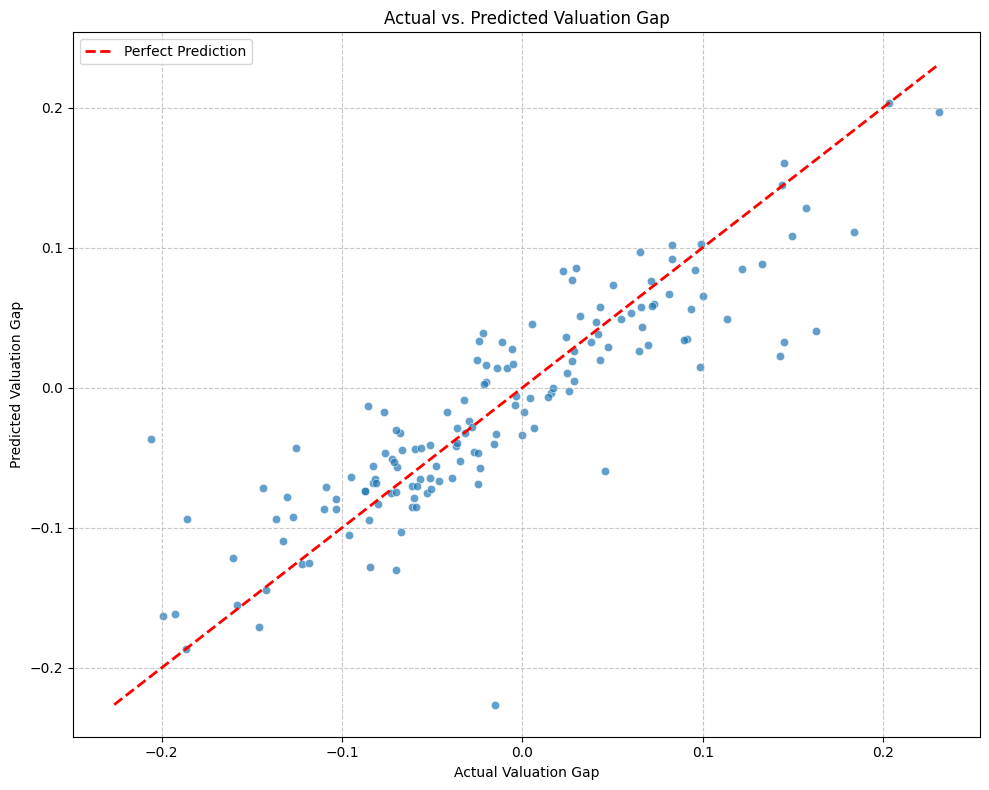

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get actual values
actual_values = df_model_temp['valuation_gap']

# Get predicted values from the last OLS model
predicted_values = ols_results_user_exact.predict(df_model_temp)

# Create a DataFrame for plotting
plot_data = pd.DataFrame({'Actual': actual_values, 'Predicted': predicted_values})

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Actual', y='Predicted', data=plot_data, alpha=0.7)

# Add a line for perfect prediction (y=x)
max_val = plot_data[['Actual', 'Predicted']].max().max()
min_val = plot_data[['Actual', 'Predicted']].min().min()
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted Valuation Gap')
plt.xlabel('Actual Valuation Gap')
plt.ylabel('Predicted Valuation Gap')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
import statsmodels.api as sm
from statsmodels.stats.api import het_breuschpagan

# Ensure ols_results_user_exact and df_model_temp are available
# If this cell is run independently, these would need to be re-created
if 'ols_results_user_exact' not in locals():
    print("Error: OLS model results not found. Please run previous OLS modeling cells.")
else:
    print("--- Breusch-Pagan Test for Heteroskedasticity ---")
    # Get residuals and exogenous variables from the last model
    residuals = ols_results_user_exact.resid
    # The exog from the dmatrices call already excludes the intercept if using '+ 0'
    exog = ols_results_user_exact.model.exog

    # Add a constant to exog for the Breusch-Pagan test as it requires one
    exog_with_constant = sm.add_constant(exog, prepend=False)

    # Perform the Breusch-Pagan test
    # The test returns: LM statistic, p-value (LM test), F-statistic, p-value (F test)
    bp_test = het_breuschpagan(residuals, exog_with_constant)

    labels = ['LM Statistic', 'LM Test p-value', 'F-Statistic', 'F-Test p-value']
    print(dict(zip(labels, bp_test)))

    if bp_test[3] < 0.05:
        print("Conclusion: The F-test p-value is less than 0.05, indicating significant heteroskedasticity.")
        print("It is advisable to use robust standard errors (e.g., HAC).")
    else:
        print("Conclusion: The F-test p-value is greater than 0.05, indicating no significant heteroskedasticity.")

    print("\n--- OLS Model Summary with HAC (Heteroskedasticity-Consistent) Standard Errors ---")
    # Recalculate standard errors using HAC method, 'HC3' is a common choice
    # This uses the original ols_results_user_exact which intrinsically knows its exog
    hac_results = ols_results_user_exact.get_robustcov_results(cov_type='HC3')
    print(hac_results.summary())

--- Breusch-Pagan Test for Heteroskedasticity ---
{'LM Statistic': np.float64(6.250370107231474), 'LM Test p-value': np.float64(0.10004461600294709), 'F-Statistic': np.float64(2.1165329699560402), 'F-Test p-value': np.float64(0.10071903480322694)}
Conclusion: The F-test p-value is greater than 0.05, indicating no significant heteroskedasticity.

--- OLS Model Summary with HAC (Heteroskedasticity-Consistent) Standard Errors ---
                                 OLS Regression Results                                
Dep. Variable:          valuation_gap   R-squared (uncentered):                   0.767
Model:                            OLS   Adj. R-squared (uncentered):              0.762
Method:                 Least Squares   F-statistic:                              93.63
Date:                Sun, 03 May 2026   Prob (F-statistic):                    9.35e-34
Time:                        11:24:56   Log-Likelihood:                          257.04
No. Observations:                 148   A

### Residual Analysis

### Quantile Regression on Differenced Valuation Gap

In [52]:
import pandas as pd
import statsmodels.formula.api as smf

# Ensure df_model is available and contains necessary columns
# If this cell is run independently, re-create df_model from df after dropping NaNs
if 'df_model' not in locals() or df_model.empty:
    model_columns = ['valuation_gap', 'delta_repo', 'regime']
    df_model = df.dropna(subset=model_columns).copy()

# Create the differenced valuation_gap
# It's important to group by city before differencing to avoid differencing across cities.
df_model['valuation_gap_diff'] = df_model.groupby('city')['valuation_gap'].diff()

print(f"DataFrame shape for differenced model: {df_model.shape}")

# Drop NaNs created by differencing for the target variable
df_model_diff = df_model.dropna(subset=['valuation_gap_diff']).copy()

print(f"DataFrame shape after dropping NaNs from differenced variable: {df_model_diff.shape}")

# Define the quantiles for regression
quantiles = [0.1, 0.5, 0.9]

# Define the formula for quantile regression with interaction
# C(regime) treats 'regime' as a categorical variable
formula_diff = "valuation_gap_diff ~ delta_repo * C(regime)"

print(f"\nFitting Quantile Regression models for formula: {formula_diff}")

for q in quantiles:
    print(f"\n--- Quantile Regression for Tau = {q} ---")
    try:
        # Fit the Quantile Regression model
        mod_diff = smf.quantreg(formula_diff, df_model_diff)
        res_diff = mod_diff.fit(q=q)

        # Print the summary of the results
        print(res_diff.summary())

    except Exception as e:
        print(f"An error occurred during Quantile Regression for tau={q}: {e}")
        print("Please check your data and formula.")

DataFrame shape for differenced model: (155, 24)
DataFrame shape after dropping NaNs from differenced variable: (151, 24)

Fitting Quantile Regression models for formula: valuation_gap_diff ~ delta_repo * C(regime)

--- Quantile Regression for Tau = 0.1 ---
                         QuantReg Regression Results                          
Dep. Variable:     valuation_gap_diff   Pseudo R-squared:              0.01438
Model:                       QuantReg   Bandwidth:                     0.06027
Method:                 Least Squares   Sparsity:                       0.4081
Date:                Sun, 03 May 2026   No. Observations:                  151
Time:                        11:40:08   Df Residuals:                      145
                                        Df Model:                            5
                                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

### Stepwise Regression for `valuation_gap_diff`

I will use a forward stepwise selection method to identify the most statistically significant predictors for the `valuation_gap_diff` by building Ordinary Least Squares (OLS) models. This process iteratively adds the variable that most improves the model's fit (based on p-value) until no more significant improvements can be made.

Calculating correlations for DataFrame of shape: (151, 24)

Correlations with valuation_gap_diff:


,valuation_gap_diff
valuation_gap_diff,1.000000
valuation_gap,0.457967
rent_growth,0.334907
repo_growth_ma2,0.089431
delta_repo,0.084601
repo_growth,0.079255
hpi_lag,0.024148
hpi_growth_ma3,0.014585
policy_shock1,0.012611
year_quarter,-0.013186


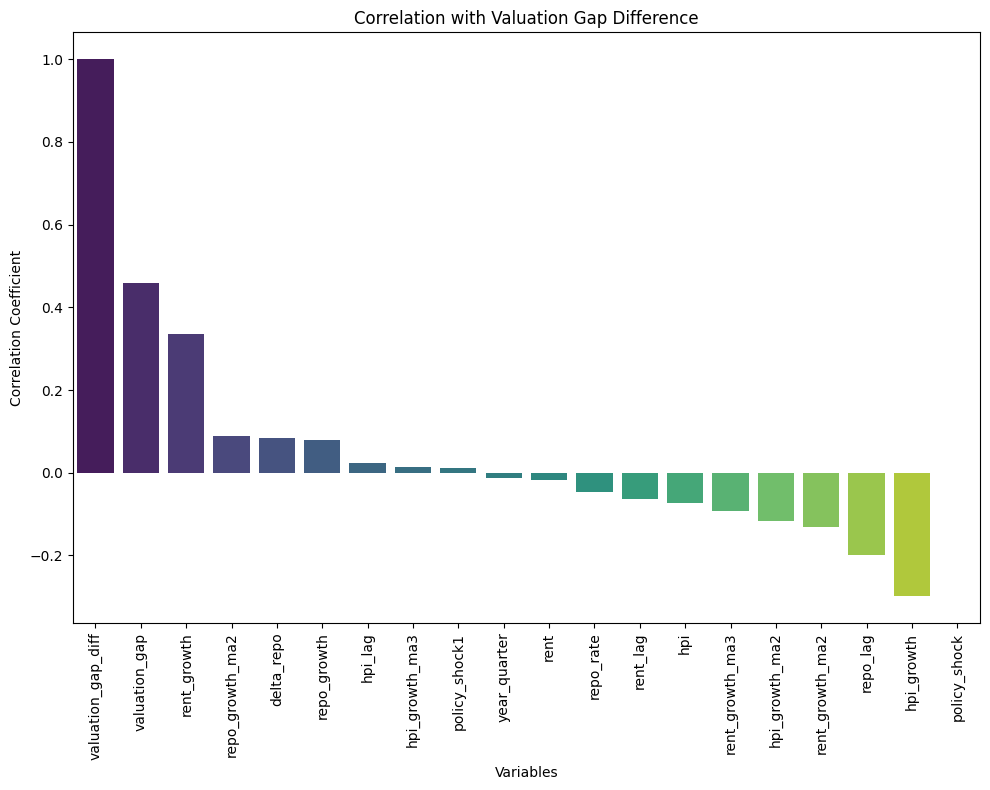

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure df_model_diff is available
# (This check is for robustness if the cell is run out of sequence)
if 'df_model_diff' not in locals() or df_model_diff.empty:
    if 'df' not in locals():
        df = pd.read_csv('/content/final_model_dataset.csv')
    if 'year_quarter' not in df.columns:
        df['year_quarter'] = df['quarter'].str.extract(r'Q(\d) (\d{4})').astype(int).pipe(lambda x: x[1] * 4 + x[0] - 1)
    df = df.sort_values(by=['city', 'year_quarter'])
    model_columns = ['valuation_gap', 'delta_repo', 'regime']
    df_model = df.dropna(subset=model_columns).copy()
    df_model['valuation_gap_diff'] = df_model.groupby('city')['valuation_gap'].diff()
    df_model_diff = df_model.dropna(subset=['valuation_gap_diff']).copy()

print(f"Calculating correlations for DataFrame of shape: {df_model_diff.shape}")

# Calculate the correlation matrix
# Exclude non-numeric columns and the 'city' column for correlation calculation
numeric_df = df_model_diff.select_dtypes(include=['number'])

# Calculate correlations with 'valuation_gap_diff'
correlations = numeric_df.corr()['valuation_gap_diff'].sort_values(ascending=False)

print("\nCorrelations with valuation_gap_diff:")
display(correlations)

# Optional: Visualize the top/bottom correlations
plt.figure(figsize=(10, 8))
sns.barplot(x=correlations.index, y=correlations.values, hue=correlations.index, palette='viridis', legend=False) # Fixed FutureWarning
plt.title('Correlation with Valuation Gap Difference')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [53]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd

# Ensure df_model_diff is available and contains necessary columns from previous cells
# This robustness check is crucial if running this cell in isolation
if 'df_model_diff' not in locals() or df_model_diff.empty:
    if 'df' not in locals():
        df = pd.read_csv('/content/final_model_dataset.csv')
    if 'year_quarter' not in df.columns:
        df['year_quarter'] = df['quarter'].str.extract(r'Q(\d) (\d{4})').astype(int).pipe(lambda x: x[1] * 4 + x[0] - 1)
    df = df.sort_values(by=['city', 'year_quarter'])
    model_columns = ['valuation_gap', 'delta_repo', 'regime']
    df_model = df.dropna(subset=model_columns).copy()
    df_model['valuation_gap_diff'] = df_model.groupby('city')['valuation_gap'].diff()
    df_model_diff = df_model.dropna(subset=['valuation_gap_diff']).copy()

print(f"DataFrame shape for stepwise regression: {df_model_diff.shape}")

# Define the dependent variable
dependent_variable = 'valuation_gap_diff'

# Define candidate independent variables
# Excluding identifiers, the original valuation_gap, and highly correlated derivatives if main is present
candidate_variables = [
    'repo_rate', 'hpi_lag', 'rent_lag', 'repo_growth', 'repo_lag',
    'delta_repo', 'policy_shock1', # policy_shock is similar to delta_repo in impact
    'rent_growth_ma2', 'hpi_growth_ma2', 'repo_growth_ma2',
    'C(regime)' # Treat regime as categorical
]

# Remove any candidate variables that are not present in df_model_diff
candidate_variables = [col for col in candidate_variables if col.replace('C(','').replace(')','') in df_model_diff.columns or col.startswith('C(')]

def forward_stepwise_selection(data, dependent, candidates, p_threshold=0.05):
    """
    Performs forward stepwise selection using OLS to find the best subset of predictors.

    Args:
        data (pd.DataFrame): The DataFrame containing all variables.
        dependent (str): The name of the dependent variable.
        candidates (list): A list of candidate independent variable names.
        p_threshold (float): The p-value threshold for adding variables.

    Returns:
        str: The final OLS formula.
        statsmodels.regression.linear_model.RegressionResultsWrapper: The results object of the final OLS model.
    """
    selected_variables = []
    best_r_squared = 0.0
    current_formula = ''
    current_model = None

    while True:
        add_variable = None
        best_p_value = p_threshold # Initialize with threshold, looking for better (smaller) p-value

        remaining_candidates = [v for v in candidates if v not in selected_variables]

        for candidate in remaining_candidates:
            test_formula = f"{dependent} ~ {' + '.join(selected_variables + [candidate])}"
            # Handle cases where no variables are selected yet (only intercept)
            if not selected_variables and not candidate:
                test_formula = f"{dependent} ~ 1"
            elif not test_formula.startswith(f"{dependent} ~ "):
                test_formula = f"{dependent} ~ 1 + {' + '.join(selected_variables + [candidate])}" # Add intercept if not explicitly included

            try:
                model = smf.ols(formula=test_formula, data=data).fit()
                # Find the p-value for the newly added variable
                # This is a simplification; a more robust approach would check overall model significance
                # or adjusted R-squared improvement. Here, we prioritize the new variable's p-value.
                # For 'C(regime)', smf.ols expands it to dummy variables, so we check the p-value
                # for the component dummy variables. We'll check if any part of the new variable is significant.
                if candidate.startswith('C('):
                    # For categorical variables, check if any of its dummy components are significant
                    p_values_for_candidate = model.pvalues.filter(regex=candidate.replace('C(','C(').replace(')',').*'))
                    min_p_for_candidate = p_values_for_candidate.min() if not p_values_for_candidate.empty else 1.0
                else:
                    min_p_for_candidate = model.pvalues.get(candidate, 1.0) # 1.0 if not found (e.g., if dropped due to collinearity)

                if min_p_for_candidate < best_p_value:
                    best_p_value = min_p_for_candidate
                    add_variable = candidate

            except Exception as e:
                # print(f"Could not fit model with {test_formula}: {e}") # Debugging
                continue

        if add_variable:
            selected_variables.append(add_variable)
            current_formula = f"{dependent} ~ {' + '.join(selected_variables)}"
            current_model = smf.ols(formula=current_formula, data=data).fit()
            # print(f"Added: {add_variable}, New Formula: {current_formula}") # Debugging
        else:
            break # No more variables to add

    final_formula = f"{dependent} ~ {' + '.join(selected_variables)}" if selected_variables else f"{dependent} ~ 1"
    final_model = smf.ols(formula=final_formula, data=data).fit()

    return final_formula, final_model

# Run forward stepwise selection
final_formula, final_model_results = forward_stepwise_selection(df_model_diff, dependent_variable, candidate_variables)

print(f"\n--- Final Model from Forward Stepwise Selection ---")
print(f"Formula: {final_formula}")
print(final_model_results.summary())

DataFrame shape for stepwise regression: (151, 24)

--- Final Model from Forward Stepwise Selection ---
Formula: valuation_gap_diff ~ repo_lag + rent_growth_ma2
                            OLS Regression Results                            
Dep. Variable:     valuation_gap_diff   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     4.957
Date:                Sun, 03 May 2026   Prob (F-statistic):            0.00830
Time:                        11:44:03   Log-Likelihood:                 152.28
No. Observations:                 145   AIC:                            -298.6
Df Residuals:                     142   BIC:                            -289.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t 

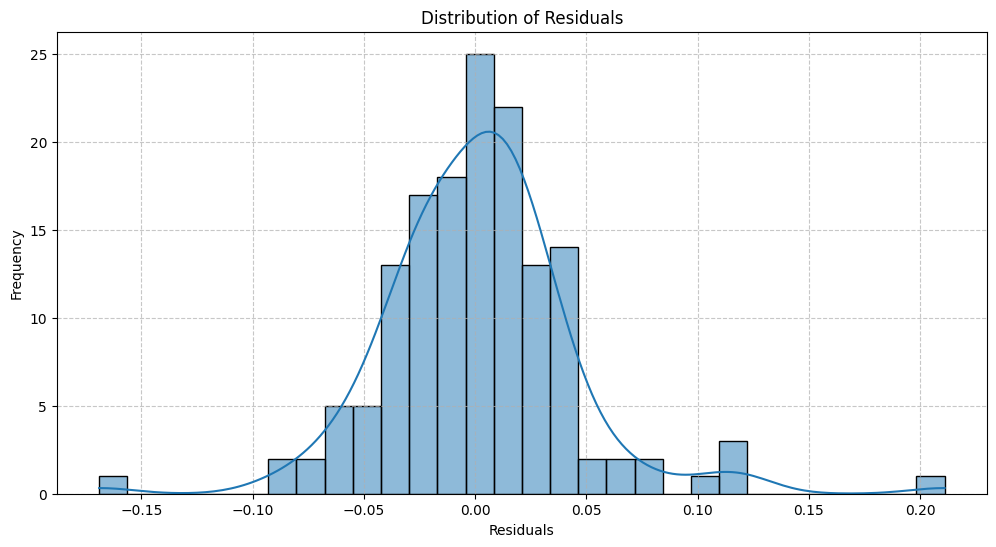

<Figure size 800x600 with 0 Axes>

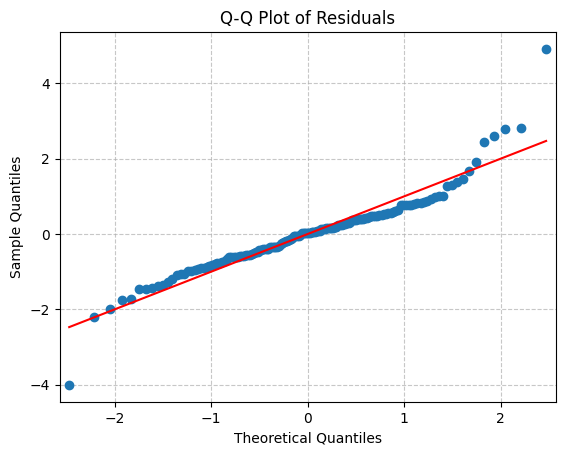

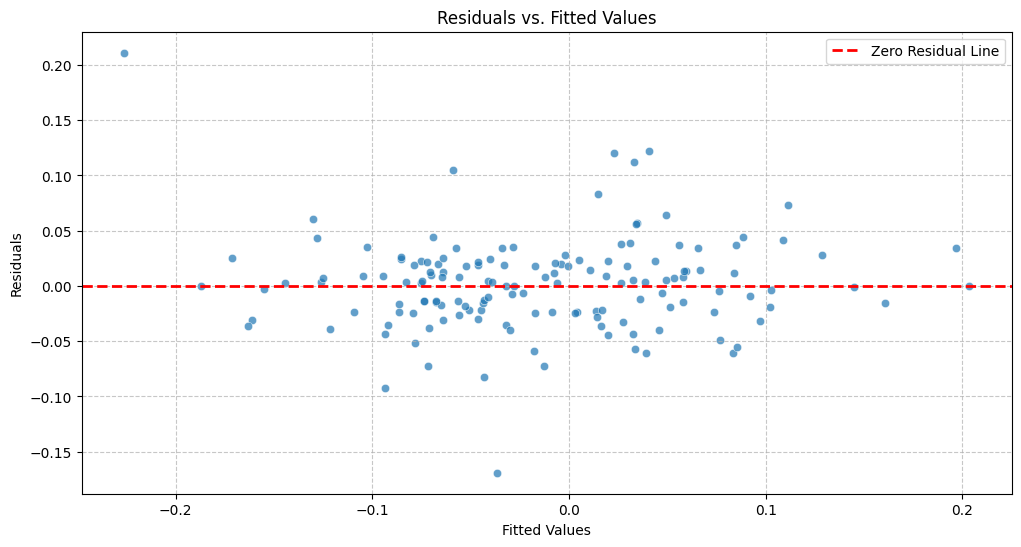

Interpretation Guide:
  - **Histogram**: Should approximate a bell-shaped curve for normality.
  - **Q-Q Plot**: Points should fall approximately along the 45-degree line for normality.
  - **Residuals vs. Fitted Values**: Should show no discernible pattern (e.g., funnel shape or curve). Random scatter around zero indicates homoskedasticity and linearity.


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Ensure ols_results_user_exact and df_model_temp are available
if 'ols_results_user_exact' not in locals() or 'df_model_temp' not in locals():
    print("Error: OLS model results or DataFrame not found. Please run previous OLS modeling cells.")
else:
    residuals = ols_results_user_exact.resid
    fitted_values = ols_results_user_exact.fittedvalues

    # 1. Histogram of Residuals to check for normality
    plt.figure(figsize=(12, 6))
    sns.histplot(residuals, kde=True, bins=30)
    plt.title('Distribution of Residuals')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # 2. Q-Q plot for Normality
    plt.figure(figsize=(8, 6))
    sm.qqplot(residuals, line='s', fit=True)
    plt.title('Q-Q Plot of Residuals')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # 3. Residuals vs. Fitted Values plot to check for homoskedasticity and linearity
    plt.figure(figsize=(12, 6))
    sns.scatterplot(x=fitted_values, y=residuals, alpha=0.7)
    plt.axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Residual Line')
    plt.title('Residuals vs. Fitted Values')
    plt.xlabel('Fitted Values')
    plt.ylabel('Residuals')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

    print("Interpretation Guide:")
    print("  - **Histogram**: Should approximate a bell-shaped curve for normality.")
    print("  - **Q-Q Plot**: Points should fall approximately along the 45-degree line for normality.")
    print("  - **Residuals vs. Fitted Values**: Should show no discernible pattern (e.g., funnel shape or curve). Random scatter around zero indicates homoskedasticity and linearity.")